# Step 1: Environment Setup
installing required libraries like pandas for data loading and manipulation, numpy for matrix calculations, matplotlib for data visualization, scikit-learn for using pretrained models, tensorflow for building, training, and deploying deep learning models

# Step 2: Importing necessary libraries and packages

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
# Loading and inspecting dataset
df = pd.read_csv('/content/Job_3_Resource_sentiment.csv')


# Step 3: Loading and Inspecting Dataset
We see the information, overview, rows and columns present in the data. Also we look at the missing values if present.

In [4]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [7]:
df.rename(columns={'Positive':'sentiment'}, inplace=True)
# inplace=True: Modifies the original object (e.g., a DataFrame) and typically returns None.

In [8]:
df.rename(columns={'im getting on borderlands and i will murder you all ,':'text'}, inplace=True)
#

# Step 4: Data Cleaning
We drop the missing values if the number of missing data is negligible or we fill it up with the average or mean values if the data is not negligible. Also we drop any unnecessary columns.

In [9]:
df.isnull().sum()

,0
2401,0
Borderlands,0
sentiment,0
text,686


In [10]:
df.drop(columns=['2401','Borderlands'])

,sentiment,text
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...
...,...,...
74676,Positive,Just realized that the Windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...
74679,Positive,Just realized between the windows partition of...


In [11]:
df['text'] = df['text'].astype(str)

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [13]:
df['text'].head()


,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...


# Step 5: Encode Target Labels
We encode target labels because most machine learning models operate on numerical data, not raw categorical strings; converting labels into numbers allows algorithms to compute loss, gradients, and predictions efficiently while preserving class distinctions. The choice of encoding depends on the problem: for classification, we often use integer encoding (e.g., via LabelEncoder) or one-hot encoding (e.g., OneHotEncoder or pd.get_dummies) to avoid implying ordinal relationships between classes; for binary labels, simple 0/1 mapping is common; and for neural networks, one-hot vectors or even embeddings may be used depending on complexity. In Python, typical approaches include from sklearn.preprocessing import LabelEncoder, OneHotEncoder, using LabelEncoder().fit_transform(y) for integer labels, or OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1,1)), and in pandas pd.get_dummies(y)—each ensuring the model receives a mathematically usable representation of the targets.

In [14]:
# Encode the target column
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(le.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


In [15]:
df.sample(5)

,2401,Borderlands,sentiment,text,sentiment_encoded
41241,1477,Battlefield,Negative,eaaccess eahelp on an xbox one and currently i...,1
44931,11716,Verizon,Negative,verizon switching phone carrier you guys are t...,1
63678,7713,MaddenNFL,Negative,easports no tone on eamaddennfl and game mish...,1
39395,5562,Hearthstone,Negative,its actually impossible to win hearthstone games,1
2973,1715,CallOfDutyBlackopsColdWar,Negative,i tried the new electronic auto sprint in,1


# Step 6: Text Tokenization and Padding
We perform text tokenization and padding because raw text is unstructured and variable in length, while machine learning models—especially neural networks—require fixed-size numerical inputs. Tokenization converts text into discrete units (words, subwords, or characters) and maps them to integers so models can process semantic patterns, while padding ensures all sequences have the same length by adding special tokens (usually zeros) to shorter sequences, enabling efficient batch processing without shape mismatches. In Python, this is commonly done using Keras utilities like Tokenizer() to build a vocabulary and convert text via texts_to_sequences(), followed by pad_sequences(sequences, maxlen=..., padding='post'); in modern NLP pipelines (e.g., Hugging Face Transformers), tokenizers handle both steps together using methods like tokenizer(texts, padding=True, truncation=True, return_tensors="pt"), producing uniform tensor inputs ready for models.

In [16]:
# Tokenizer
tokenizer = Tokenizer(num_words = 10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text'])


seq = tokenizer.texts_to_sequences(df['text'])

In [17]:
# Padding

max_length = 100
X = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

In [18]:
y = df['sentiment_encoded'].values

In [19]:
X

array([[   3,  101,  378, ...,    0,    0,    0],
       [  31,  158,   14, ...,    0,    0,    0],
       [  31,  378,   14, ...,    0,    0,    0],
       ...,
       [  22, 1838,    2, ...,    0,    0,    0],
       [  22, 1838,  694, ...,    0,    0,    0],
       [  22,   32,    2, ...,    0,    0,    0]], dtype=int32)

In [20]:
y

array([3, 3, 3, ..., 3, 3, 3])

# Step 7: Train/ Validation / Test Split
We split data into train, validation, and test sets to get an unbiased estimate of how well a model will generalize to unseen data and to avoid overfitting during development. The training set is used to learn model parameters, the validation set is used during tuning (e.g., hyperparameters, model selection, early stopping) so we don’t indirectly “peek” at the test data, and the test set is held out until the very end to provide a final, honest evaluation; without this separation, performance metrics can become overly optimistic because the model (or the human tuning it) has effectively memorized patterns specific to the dataset. In Python, this is typically done with from sklearn.model_selection import train_test_split, e.g., first splitting into train+temp and test, then splitting temp into validation (X_train, X_temp, y_train, y_temp = train_test_split(..., test_size=0.3); X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)), ensuring each subset remains statistically representative.

In [21]:
# Train Test Splitting

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# This code performs a two-stage split to divide a dataset (X,y) into three distinct sets—Train (70%), Validation (15%), and Test (15%)—using scikit-learn. It ensures reproducible shuffling (random_state=42). This method prepares data for training, hyperparameter tuning (validation), and final evaluation
print("Train:",X_train.shape, y_train.shape)
print("Validation:",X_val.shape, y_val.shape)
print("Test:",X_test.shape, y_test.shape)

Train: (52276, 100) (52276,)
Validation: (11202, 100) (11202,)
Test: (11203, 100) (11203,)


In [22]:

# Bias handling(class weights)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4436098530873744), 1: np.float64(0.8236591668242264), 2: np.float64(1.0105938756572843), 3: np.float64(0.906059345535219)}


# Step 8: Choosing Learning Model: LSTM
We choose an LSTM (Long Short-Term Memory) model when the task involves sequential or time-dependent data—like text, time series, or speech—because it can retain and use information from earlier steps in a sequence, something standard feedforward networks cannot do. Unlike basic RNNs, LSTMs address the vanishing gradient problem by using gated mechanisms (input, forget, and output gates) that control what information is kept, updated, or discarded, allowing the model to learn long-range dependencies (e.g., understanding context across a sentence). This makes LSTMs especially useful in NLP tasks such as sentiment analysis or language modeling, where word order and context matter. In Python, using Keras, you typically define it as model.add(LSTM(units, return_sequences=...)) within a sequential model, often preceded by an Embedding layer and followed by dense layers for prediction, enabling the network to learn meaningful patterns from tokenized and padded sequences.

In [23]:
max_words = 10000

# LSTM
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,332 (5.26 MB)

 Trainable params: 1,379,332 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

# Step 9: Compiling Model
We compile a model to specify exactly how it should learn before training begins—this step binds together the loss function (what error to minimize), the optimizer (how weights are updated), and evaluation metrics (how performance is tracked). Without compilation, the model has an architecture but no defined training logic, so it cannot compute gradients or update parameters. The loss function depends on the task (e.g., binary_crossentropy for binary classification, categorical_crossentropy for multi-class), the optimizer (like Adam or SGD) controls the learning dynamics, and metrics (like accuracy) provide interpretable feedback during training. In Python, using Keras, this is done with model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']), which prepares the model internally for efficient forward and backward passes during model.fit().

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 10: Training Model
We train the model to actually learn patterns from data by adjusting its internal parameters (weights) so that predictions get closer to the true labels. Up to this point, the model is just a structure with randomly initialized weights; during training, it performs forward passes to make predictions, computes error using the loss function, and then uses backpropagation with an optimizer to update weights iteratively over many epochs. This process allows the model to capture relationships in the data (e.g., sequence patterns in text for an LSTM) rather than guessing randomly. In Python, using Keras, training is done with model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=..., batch_size=...), where the validation set helps monitor generalization and detect overfitting during the learning process.

In [25]:

early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)


Epoch 1/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6081 - loss: 0.9580 - val_accuracy: 0.7217 - val_loss: 0.7149
Epoch 2/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7809 - loss: 0.5838 - val_accuracy: 0.7767 - val_loss: 0.5856
Epoch 3/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8381 - loss: 0.4348 - val_accuracy: 0.7945 - val_loss: 0.5426
Epoch 4/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8702 - loss: 0.3412 - val_accuracy: 0.8119 - val_loss: 0.5342
Epoch 5/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8911 - loss: 0.2874 - val_accuracy: 0.8245 - val_loss: 0.5265
Epoch 6/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9059 - loss: 0.2450 - val_accuracy: 0.8241 - val_loss: 0.5554
Epoch 7/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9162 - loss: 0.2155 - val_accuracy: 0.8353 - val_loss: 0.5614
Epoch 8/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9242 -

# Step 11: Visualize Performance
We visualize model performance to diagnose how learning is progressing and detect issues that raw metrics alone can hide, such as overfitting, underfitting, or unstable training. By plotting training vs. validation loss and accuracy over epochs, you can see patterns—e.g., training loss decreasing while validation loss increases (overfitting), or both staying high (underfitting)—which directly informs decisions like adjusting model complexity, learning rate, or regularization. Visualization also helps verify whether training has converged or if more epochs are needed. In Python, this is typically done by capturing the history from model.fit() in Keras and plotting it using matplotlib, e.g., history.history['loss'] and history.history['val_loss'], giving a clear, interpretable view of model behavior over time.


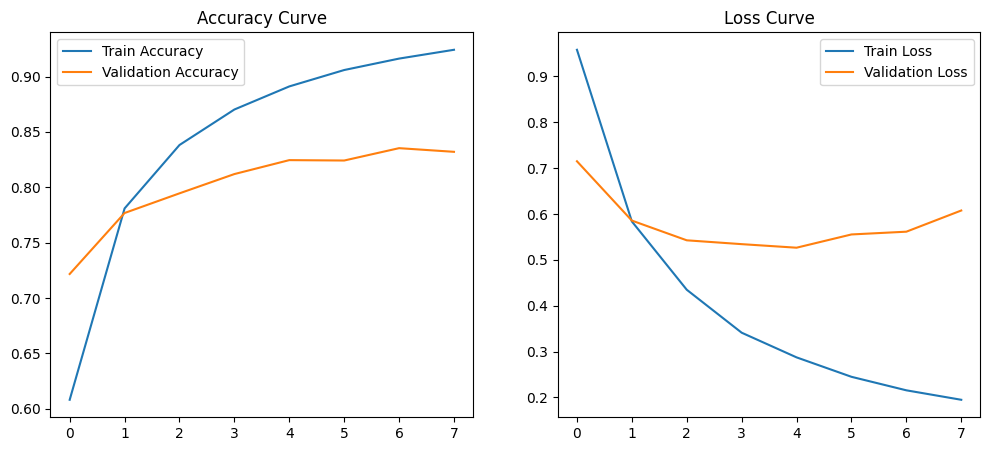

In [26]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

# Step 12: Generalization Checking
We perform this step to evaluate whether the model has learned the right level of complexity—not just memorized the training data (overfitting) or failed to learn meaningful patterns at all (underfitting). A model that looks “accurate” on training data can still fail in real use if it doesn’t generalize, so detecting these conditions helps you decide what to fix: overfitting suggests adding regularization, more data, or simplifying the model, while underfitting points to increasing model capacity, training longer, or improving features. This step acts as a diagnostic checkpoint between training and deployment, ensuring the model’s performance is both strong and reliable, rather than misleading due to poor generalization.

In [27]:

if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is generalizing well")

⚠️ Possible Overfitting detected


# Step 13: Model Evaluation and saving
We perform model evaluation and saving to finalize and preserve a reliable version of the model after training. Evaluation uses the untouched test set to provide an unbiased estimate of real-world performance, confirming that the model generalizes beyond the data it was trained and tuned on; without this step, reported accuracy can be misleading. Saving the model then ensures that this validated state—its architecture, learned weights, and sometimes preprocessing steps—can be reused without retraining, which is critical for deployment, reproducibility, and future inference. In Python, using Keras, evaluation is done with model.evaluate(X_test, y_test), and saving with model.save("model.h5") (or the newer .keras format), allowing you to later reload it via load_model() and use it directly for predictions.

In [28]:
# Evaluation
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save Model
model.save("sentiment_analysis_model.keras")
print("✅ Model saved successfully")

351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.8140676604480943
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1942
           1       0.85      0.85      0.85      3306
           2       0.77      0.82      0.79      2737
           3       0.84      0.79      0.82      3218

    accuracy                           0.81     11203
   macro avg       0.81      0.81      0.81     11203
weighted avg       0.82      0.81      0.81     11203

✅ Model saved successfully


In [29]:
# Testing with new Text
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad)[0]
    return le.classes_[probs.argmax()], probs

texts = [
    "I love this game so much",
    "This game is terrible",
    "I have no opinion",
    "What is this even about?",
    "the game was bad",
    "Taurat didn't think good of the game"
]

for t in texts:
    pred, prob = predict_sentiment(t)
    print(t, "->", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
I love this game so much -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This game is terrible -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
I have no opinion -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
What is this even about? -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
the game was bad -> Neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Taurat didn't think good of the game -> Positive
